(step_by_step)=

# Step-by-Step Workflow

`Gal3D` mainly uses the {py:class}`Gal3DAnalyzer <gal3d.analyzer.Gal3DAnalyzer>` class to build 3D galaxy models. Initializing {py:class}`Gal3DAnalyzer <gal3d.analyzer.Gal3DAnalyzer>` requires the following components:

- {py:class}`Particles <gal3d.point.Particles>`, which initializes the particle data and provides density estimates at arbitrary positions;
- {py:class}`SphField <gal3d.field.spherical_field.field.SphField>`, which constructs a smoothed density field and its associated interpolators from the particle data;
- {py:class}`Structure3D <gal3d.shape.Structure3D>`, which defines the target shape, the error function, and related settings;
- {py:class}`Optimizer <gal3d.optimization.optimizer.Optimizer>`, which performs the parameter optimization.

(particle-initialization)=

## Particle Initialization

The goal of particle initialization is to enable density estimation at arbitrary positions from a particle distribution defined by positions and masses.

This section shows how to initialize the particle positions and masses and construct a density-query object. The main class used here is {py:class}`Particles <gal3d.point.Particles>`.

To initialize the particle data, you need to provide the particle positions (`pos`) and masses (`mass`). As in the previous examples, we use particle data from a galaxy in the TNG50-1 simulation.

In [1]:
import numpy as np
from AnastrisTNG import TNGsimulation


path = '/home/yxi/Simulation/sims/TNG50-1/output'
snap =99
snapshot = TNGsimulation.Snapshot(path,snap)

ID = 8 
sub = snapshot.load_particle(ID,order='star,gas')
sub.physical_units()
coor_trans = sub.face_on(alignwith='star',rmax=8)

pos = sub.s['pos'].view(np.ndarray)
mass = sub.s['mass'].view(np.ndarray)

### Initializing the `Particles` Class

Use the {py:class}`Particles <gal3d.point.Particles>` class to initialize the particle positions and masses. The position array `pos` has shape `(N, 3)`, and the mass array `mass` has shape `(N,)`, where `N` is the number of particles.

```{seealso}

For a more detailed introduction to {py:class}`Particles <gal3d.point.Particles>`, including usage examples, see {ref}`Working with Particle Classes <particles>`.
```

In [2]:
print(pos.shape)
print(mass.shape)

(624045, 3)
(624045,)


In [3]:
from gal3d.point import Particles

particles = Particles(pos=pos, mass=mass, 
                recenter=False, density_estimator='DensityEstimatorSPH')

(density-field)=

## Constructing the Density Field

The purpose of this step is to build a density field once a density estimator is available for arbitrary positions. Because direct density queries can be computationally expensive, `Gal3D` constructs an intermediate field representation to reduce the cost of repeated evaluations.

Before constructing the density field, the particles must already be initialized so that the density estimator is available. See {ref}`Particle Initialization <particle-initialization>` for that step.

This section focuses on building the density field with the {py:class}`SphField <gal3d.field.spherical_field.field.SphField>` class.

The `Sph` in {py:class}`SphField <gal3d.field.spherical_field.field.SphField>` stands for *spherical*.

The basic idea of `SphField` is to cast rays outward from the center, sample how the density varies along each ray, and construct a radial density interpolator for each direction.

### Directions of the Density Probes

Pass the initialized {py:class}`Particles <gal3d.point.Particles>` object to {py:class}`SphField <gal3d.field.spherical_field.field.SphField>`.

At the same time, specify the number of density probes and the sampling method used to choose their directions.

In [4]:
from gal3d.field import SphField


field = SphField(density_source=particles,num_ray=1024,ray_method='fibonacci')

<gal3d.preprocessing.spherical_field.spherical_vector> | INFO | 1024 points on the sphere by fibonacci method have the uniformity of 99.688
<gal3d.field.SphField> | INFO | Build ray vector: 0.02 sec


```{tip}
:class: margin
In most cases, `ray_method='fibonacci'` provides more uniform angular sampling than other methods.

See {ref}`Uniform Sampling on the Sphere <spherical-sampling>` for a more detailed discussion of the Fibonacci method.
```

- `particles` s the initialized particle object, that is, an instance of{py:class}`Particles <gal3d.point.Particles>`，
- `num_ray` is the number of density probes. Each probe traces how the density changes outward from the center along one direction. The default value is `1024`.
- `ray_method` specifies how the probe directions are sampled. In most cases, these directions should be distributed uniformly over the sphere. The default is `fibonacci`.

### Radial Range of the Density Probes

After choosing the direction of each density probe, we need to define its radial range. This is done with {py:meth}`build_field_boundary <gal3d.field.spherical_field.field.SphField.build_field_boundary>`.

Both the minimum and maximum radii of each probe must be specified. Here, we set the minimum radius to `0.2` and the maximum radius to the point where the density falls to `2e4`.

In [5]:
field.build_field_boundary(inner=0.2,outer=2e4,
                            inner_mode='dist',outer_mode='value')

<gal3d.field.SphField> | INFO | Build field boundary: 2.10 sec


<SphField(num_ray=1024), [Particles(num_particles=624045, density_estimator=DensityEstimatorSPH)], inner_r=[0.2, 0.2], outer_r=[7.65, 48.4]>

After this step, you can inspect `field.inner_r` and `field.outer_r`. These are one-dimensional arrays that give the inner and outer radius of each density probe.

In [6]:
print(repr(field.inner_r))
print(repr(field.outer_r))

array([0.2, 0.2, 0.2, ..., 0.2, 0.2, 0.2], shape=(1024,))
array([10.31798343, 10.31798343, 10.5485529 , ..., 12.10489677,
       12.79660515, 12.93494683], shape=(1024,))


The figure below shows the distributions of the inner and outer radii.

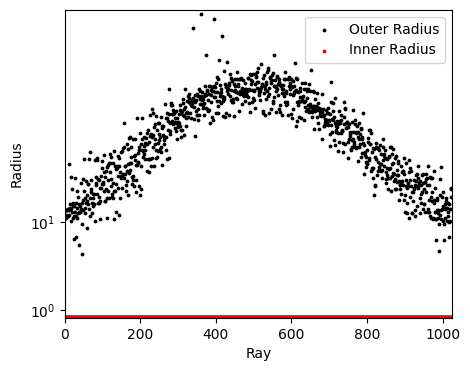

In [7]:
import matplotlib.pyplot as plt

plt.figure(dpi=100,figsize=(5,4))
plt.scatter(np.arange(1024),field.outer_r,c='k',s=3,label="Outer Radius")
plt.scatter(np.arange(1024),field.inner_r,c='r',s=3,label="Inner Radius")
plt.yscale('symlog',linthresh=8,linscale=0.2)
plt.xlim(0,1025)
plt.ylim(0.1,50)
plt.xlabel("Ray")
plt.ylabel("Radius")
plt.legend()
plt.show()

### Sampling the Radial Density Profile

Once the probe directions and radial ranges have been defined, each probe must sample the density along its radial interval in order to recover the radial density profile. This is done with {py:meth}`build_profile_sample <gal3d.field.spherical_field.field.SphField.build_profile_sample>`.

Here we set `num_p=500` and `step_mode='log'`, which means that 500 logarithmically spaced sample points are used along each direction to trace the radial density distribution.

In [7]:
field.build_profile_sample(num_p=500,step_mode='log')

<gal3d.field.SphField> | INFO | Build profile sample: 0.89 sec


<SphField(num_ray=1024), [Particles(num_particles=624045, density_estimator=DensityEstimatorSPH)], inner_r=[0.2, 0.2], outer_r=[7.65, 48.4]>

### Interpolating the Radial Density Profile

After sampling the radial density profile along each probe direction, the next step is to construct interpolators from those samples. This is done with {py:meth}`build_profile_interpolator <gal3d.field.spherical_field.field.SphField.build_profile_interpolator>`.

Here we set `interpolator_method='LU'`, which uses the Lower-Upper (LU) method for monotonic interpolation. The option `is_decreasing=True` specifies that the interpolator should be monotonic decreasing.

```{seealso}
:class: margin

See {ref}`Monotonic Smooth Interpolation <monotonic-ray>` for details of this implementation.

In [8]:
field.build_profile_interpolator(interpolator_method = 'LU', 
                                 is_decreasing=True)

<gal3d.field.SphField> | INFO | Build profile interpolator: 0.80 sec


<SphField(num_ray=1024), [Particles(num_particles=624045, density_estimator=DensityEstimatorSPH)], inner_r=[0.2, 0.2], outer_r=[7.65, 48.4]>

At this point, we have obtained a monotonic decreasing radial density interpolator for each probe direction.

### Radial Distribution of Iso-Density Surfaces

The purpose of this step is to estimate the radial distribution of iso-density surfaces and construct the corresponding interpolator, so that parameter ranges can be constrained more effectively during model fitting.

In [9]:
field.build_isodensity_profile(method='pair')

<gal3d.field.SphField> | INFO | Set isodensity sphere: 0.91 sec
<gal3d.field.SphField> | INFO | Build isodensity profile: 1.64 sec


<SphField(num_ray=1024), [Particles(num_particles=624045, density_estimator=DensityEstimatorSPH)], inner_r=[0.2, 0.2], outer_r=[7.65, 48.4]>

The figure below shows the estimated radial iso-density profile (black points), the corresponding interpolation (red line), and the relative error (green line).

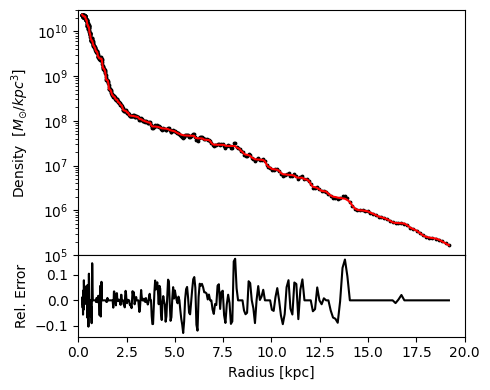

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1,dpi=100, figsize=(5, 4), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Above ax1: radial distribution
ax1.scatter(field.iso_pro_r, field.iso_pro_parameter, c='k', s=3)
ax1.plot(field.iso_pro_r, field.iso_pro_func(field.iso_pro_r), c='r')
ax1.set_yscale('log')
ax1.set_xlim(0, 20)
ax1.set_ylim(1e5, 3e10)
ax1.set_ylabel(r'Density $\ [M_{\odot}/kpc^3]$')

# Below ax2: relative error
ax2.plot(field.iso_pro_r, (field.iso_pro_parameter - field.iso_pro_func(field.iso_pro_r)) / field.iso_pro_func(field.iso_pro_r), c='k')
ax2.set_ylabel("Rel. Error")
ax2.set_xlabel("Radius [kpc]")
plt.tight_layout()
plt.subplots_adjust(hspace=0)
plt.show()

(shape-setting)=

## Shape Setup

The purpose of this step is to define the target shape before fitting.

This section focuses on shape setup using the {py:class}`Structure3D <gal3d.shape.Structure3D>` class.

### Initializing the Shape

To initialize {py:class}`Structure3D <gal3d.shape.Structure3D>`, you need to specify a shape function, a coordinate system, an error function, and an error-evaluation method.

You can inspect all available options with `Structure3D.available_options()`.

In [10]:
from gal3d.shape import Structure3D
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, Normalize

In [11]:
Structure3D.available_options()

{'coordinate': ['EulerShift', 'RotateOnly', 'ShiftEuler', 'ShiftOnly'],
 'geometry': ['Ellipsoid', 'Ellipsoid_S'],
 'error_func': ['sums_dev',
  'sums_dev_byw',
  'sums_dev_rscale',
  'sums_dev_rscale_byw'],
 'error_method': ['isodensity_fcall',
  'isodensity_dcall',
  'isodensity_dist',
  'isodensity_curve_fcall',
  'isodensity_curve_dcall',
  'isodensity_curve_dcall_azimuthal']}

Here we use `EulerShift`, which represents 3D coordinate transformations using Euler angles and translations.

We also use `Ellipsoid_S`, an ellipsoidal shape function with shape indices; `sums_dev_rscale`, a distance-squared-weighted error function; and `isodensity_curve_dcall`, which evaluates distances to iso-density surfaces.

In the printed representation of `structure`, you can see `EulerShift` and `Ellipsoid_S`, followed by their corresponding parameters and values.

In [12]:
structure = Structure3D(coordinate='EulerShift',geometry='Ellipsoid_S',error_func='sums_dev_rscale',error_method='isodensity_curve_dcall')
structure

<Structure3D|
   Coord : <EulerShift|: (
        x     = 0.000  [-0.200, 0.200]
        y     = 0.000  [-0.200, 0.200]
        z     = 0.000  [-0.200, 0.200]
        ang1  = 0.000  [-3.142, 3.142]
        ang2  = 0.000  [-1.571, 1.571]
        ang3  = 0.000  [-3.142, 3.142]
      )|>
   Geom  : <Ellipsoid_S|: (
        a       = 3.000  [0.100, inf]
        eps_ab  = 0.200  [0.001, 0.999]
        eps_bc  = 0.500  [0.001, 0.999]
        sa      = 1.000  [0.200, 2.000]
        sb      = 1.000  [0.200, 2.000]
        sc      = 1.000  [0.200, 2.000]
      )|>
   Error : sums_dev_rscale / isodensity_curve_dcall
|>

```{seealso}
:class: margin
See {ref}`Superellipsoids with Different Shape Parameters <ellipsoid-shape-show>` for visual examples of ellipsoids with different parameter combinations.
```
The left panel below shows the `z=0` slice for the standard ellipsoid case with shape indices `sa=1` and `sb=1`. Different colors correspond to different values of `eps_ab`, illustrating how the ellipticity changes.

The right panel shows how the shape indices affect the geometry. With `eps_ab = 0.2`, different values of the shape indices produce different shapes. When `sa=sb=1`, the result is a standard ellipsoid, and the slice is a standard ellipse (black solid line). When `sa=sb=0.5`, the slice becomes diamond-like (black dotted line). When `sa=sb=2`, the slice becomes boxier and more rectangular (black dashed line).

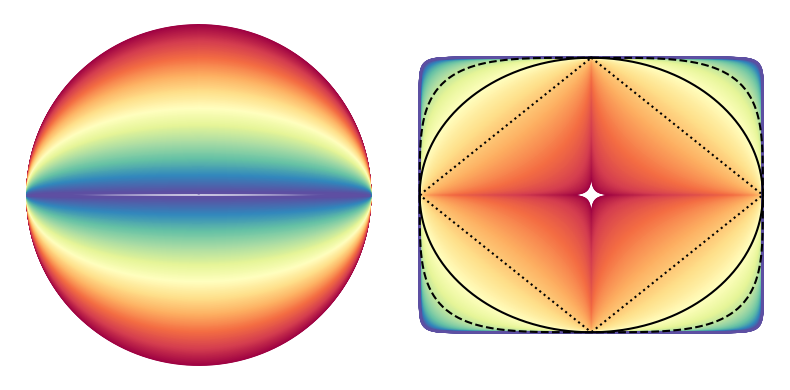

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4), dpi=100)


# left：Ellipticity
norm1 = Normalize(0.01, 0.99)
cmap1 = plt.get_cmap('Spectral')
structure.parameters['sa'] = 1
structure.parameters['sb'] = 1
for i in np.linspace(0.01, 0.99, 500):
    structure.parameters['eps_ab'] = i
    x, y = structure.generate_slice2D(500)
    ax1.plot(x, y, c=cmap1(norm1(structure.parameters['eps_ab'])))
ax1.axis('equal')
ax1.axis('off')

# right：Shape Index
smin = 0.1
smax = 10
norm2 = LogNorm(smin, smax)
cmap2 = plt.get_cmap('Spectral')
structure.parameters['eps_ab'] = 0.2
for i in np.geomspace(smin, smax, 500):
    structure.parameters['sa'] = i
    structure.parameters['sb'] = i
    x, y = structure.generate_slice2D(500)
    ax2.plot(x, y, c=cmap2(norm2(structure.parameters['sa'])))
structure.parameters['sa'] = 1
structure.parameters['sb'] = 1
x, y = structure.generate_slice2D(500)
ax2.plot(x, y, c='k')
structure.parameters['sa'] = 0.5
structure.parameters['sb'] = 0.5
x, y = structure.generate_slice2D(500)
ax2.plot(x, y, c='k', linestyle=':')
structure.parameters['sa'] = 2
structure.parameters['sb'] = 2
x, y = structure.generate_slice2D(500)
ax2.plot(x, y, c='k', linestyle='--')
ax2.axis('equal')
ax2.axis('off')


plt.tight_layout()
plt.show()

### Shape Parameters

`structure.parameters` is an instance of {py:class}`Parameters <gal3d.optimization.parameter.Parameters>`, which stores all adjustable parameters and their constraints.

```{seealso}

`parameters` supports lower and upper bounds as well as additional constraints.
You can set lower and upper bounds with {py:meth}`Parameters.set_lb <gal3d.optimization.parameter.Parameters.set_lb>` and {py:meth}`Parameters.set_ub <gal3d.optimization.parameter.Parameters.set_ub>`.
You can also add equality constraints with {py:meth}`Parameters.add_equal_constraints <gal3d.optimization.parameter.Parameters.add_equal_constraints>`.
See {ref}`Working with Parameter Classes <parameters>` for more detailed examples.
```

In [13]:
structure.parameters

Parameters(
  x       = 0.000  [-0.200, 0.200]
  y       = 0.000  [-0.200, 0.200]
  z       = 0.000  [-0.200, 0.200]
  ang1    = 0.000  [-3.142, 3.142]
  ang2    = 0.000  [-1.571, 1.571]
  ang3    = 0.000  [-3.142, 3.142]
  a       = 3.000  [0.100, inf]
  eps_ab  = 0.200  [0.001, 0.999]
  eps_bc  = 0.500  [0.001, 0.999]
  sa      = 1.000  [0.200, 2.000]
  sb      = 1.000  [0.200, 2.000]
  sc      = 1.000  [0.200, 2.000]
)

You can access the lower and upper bounds of all parameters through the `parameters.lb` and `parameters.ub` attributes, both of which return dictionaries.

In [14]:
structure.parameters.lb

{'x': -0.2,
 'y': -0.2,
 'z': -0.2,
 'ang1': -3.141592653589793,
 'ang2': -1.5707963267948966,
 'ang3': -3.141592653589793,
 'a': 0.1,
 'eps_ab': 0.001,
 'eps_bc': 0.001,
 'sa': 0.2,
 'sb': 0.2,
 'sc': 0.2}

In [26]:
structure.parameters.ub

{'x': 0.2,
 'y': 0.2,
 'z': 0.2,
 'ang1': 3.141592653589793,
 'ang2': 1.5707963267948966,
 'ang3': 3.141592653589793,
 'a': inf,
 'eps_ab': 0.99,
 'eps_bc': 0.99,
 'sa': 2.0,
 'sb': 2.0,
 'sc': 2.0}

You can also inspect the lower and upper bounds of a specific parameter, for example with `parameters['eps_bc'].lb` and `parameters['eps_bc'].ub`.

In [20]:
structure.parameters['eps_bc'].ub

0.99

(optimization)=

## Optimizer Setup

The purpose of this step is to choose and configure an optimizer for model fitting. Here we use the {py:class}`Optimizer <gal3d.optimization.optimizer.Optimizer>` class.

You can list the available optimizer plugins with {py:meth}`Optimizer.available_plugins <gal3d.optimization.optimizer.Optimizer.available_plugins>`.

In [15]:
from gal3d.optimization.optimizer import Optimizer

Optimizer.available_plugins()

['OptimizerLMFit', 'OptimizerNLopt', 'OptimizerOptimagic', 'OptimizerScipy']

You can then retrieve a specific optimizer plugin with {py:meth}`Optimizer.get_plugin <gal3d.optimization.optimizer.Optimizer.get_plugin>`. This returns a class derived from {py:class}`OptimizerBase <gal3d.optimization.optimizer.OptimizerBase>`.

In [16]:
optimizeplugin = Optimizer.get_plugin('OptimizerScipy')

You can then inspect the optimization algorithms provided by this plugin with {py:meth}`OptimizerBase.available_algorithm <gal3d.optimization.optimizer.OptimizerBase.available_algorithm>` .

In [17]:
optimizeplugin.available_algorithm()

['Nelder-Mead',
 'Powell',
 'CG',
 'BFGS',
 'Newton-CG',
 'L-BFGS-B',
 'TNC',
 'COBYLA',
 'COBYQA',
 'SLSQP',
 'trust-constr',
 'dogleg',
 'trust-ncg',
 'trust-exact',
 'trust-krylov',
 'trf',
 'dogbox',
 'lm']

Next, choose one of the available algorithms, for example `"trf"`, and use it to create an optimizer instance.

In [18]:
optimizer = optimizeplugin("trf")

```{note}
Additional optimizer settings can be configured with {py:meth}`OptimizerBase.set_options <gal3d.optimization.optimizer.OptimizerBase.set_options>`.
```

## Running the Fit

After initializing {py:class}`Particles <gal3d.point.Particles>`, {py:class}`SphField <gal3d.field.spherical_field.field.SphField>`, {py:class}`Structure3D <gal3d.shape.Structure3D>`, and {py:class}`Optimizer <gal3d.optimization.optimizer.Optimizer>`, pass them to {py:class}`Gal3DAnalyzer <gal3d.analyzer.Gal3DAnalyzer>` to start the fitting process.

In [19]:
from gal3d.analyzer import Gal3DAnalyzer

In [20]:
gal = Gal3DAnalyzer(density_source=particles, field=field, structure=structure, optimizer=optimizer)

You can then run the fit with {py:meth}`Gal3DAnalyzer.fit <gal3d.analyzer.Gal3DAnalyzer.fit>`.

In [22]:
res = gal.fit()

<gal3d.analyzer> | INFO | Using workflow: EllipsoidFitWorkflow
from <fit_workflow.py> line: 144     
  >>>  | WARNING | PoorUniformityError: skipped 14 radii from 0.6 to 0.7524
Fitting radii: 100%|██████████| 200/200 [00:16<00:00, 12.06it/s]


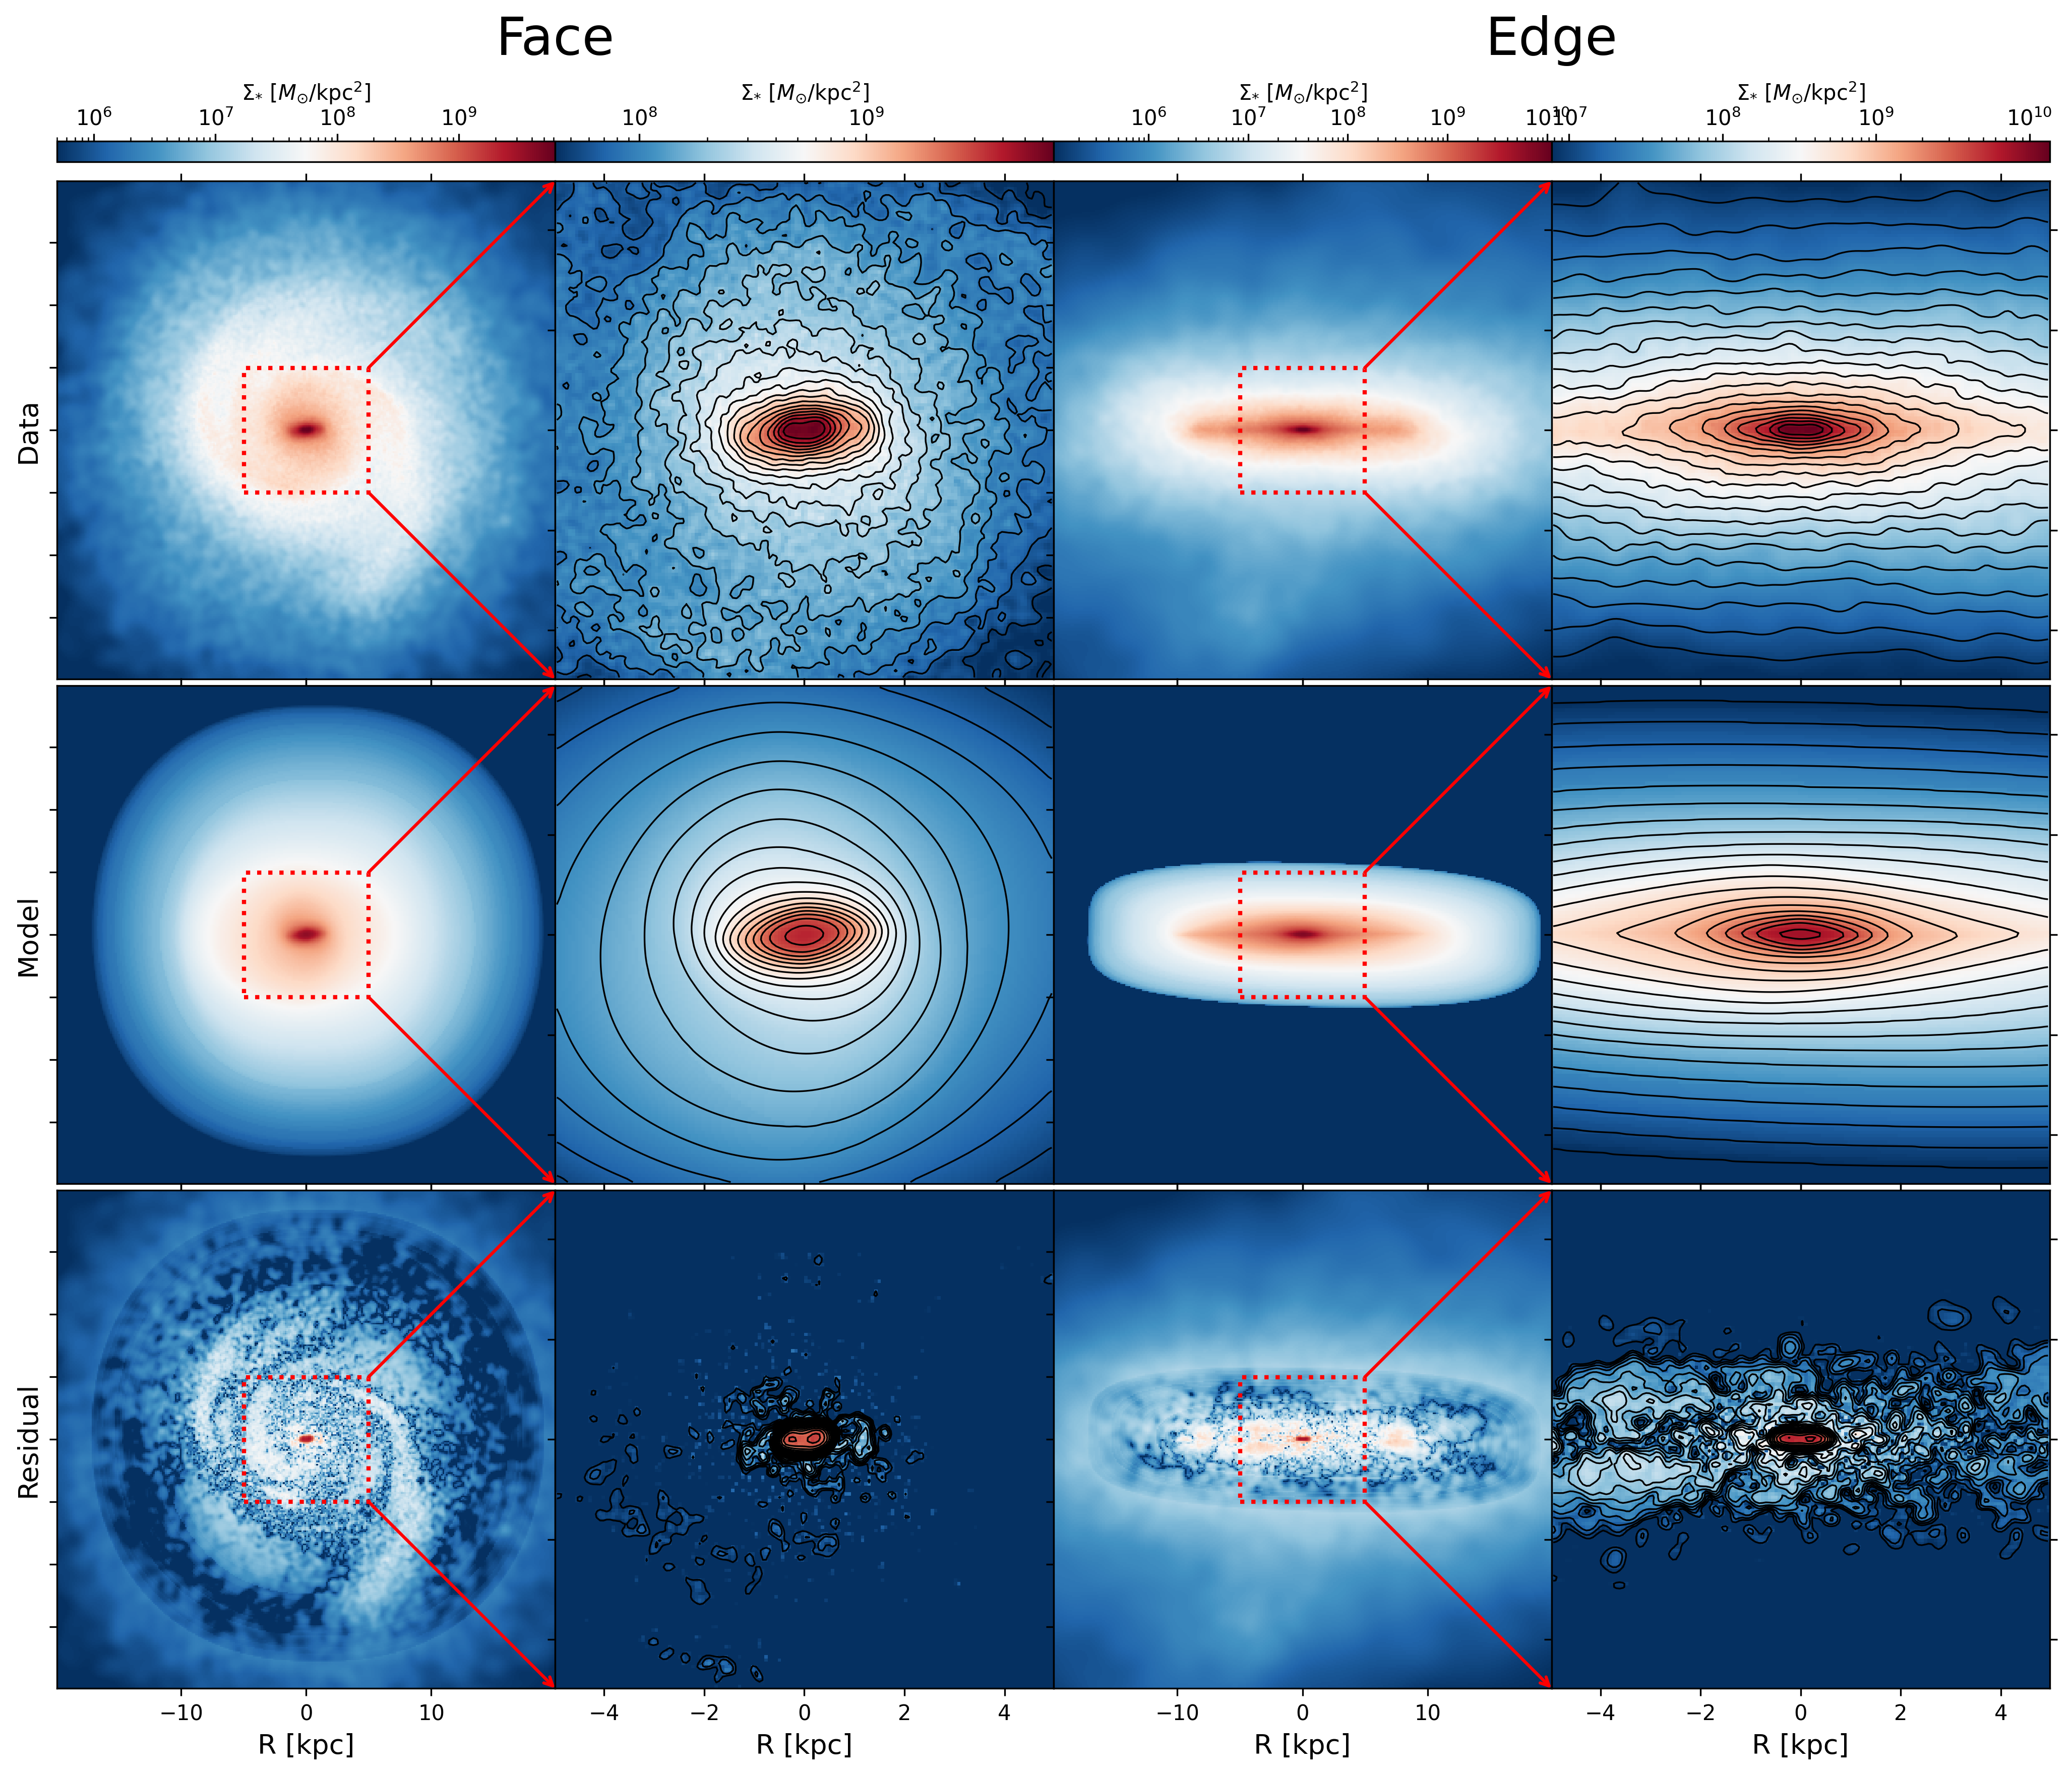

In [24]:
from gal3d.visualization import ModelProjector, show_image_model_residual

ellipsoid_s_model = ModelProjector.get_plugin('ProjectorLineIntegration')(res)

box_lh_max =res['a'][-1]*1.1
zoom_lh_max = box_lh_max/4
fig = show_image_model_residual(gal.density_source,ellipsoid_s_model,
                          large_box_x_range = (-box_lh_max,box_lh_max),
                          large_box_y_range= (-box_lh_max,box_lh_max),
                          zoom_x_range=(-zoom_lh_max,zoom_lh_max),
                          zoom_y_range=(-zoom_lh_max,zoom_lh_max),
                          depth_z_range=(-box_lh_max,box_lh_max),
                          cmap="RdBu_r",
                          nbins_large=300,
                          nbins_zoom=150,
                          nlevels_large=0,
                          nlevels_zoom=22)